In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
reg  = pd.read_csv('anonymisedData/studentRegistration.csv')
info = pd.read_csv('anonymisedData/studentInfo.csv')
vle  = pd.read_csv('anonymisedData/vle.csv')
e3 = pd.read_csv("partialratios.csv")
course = pd.read_csv('anonymisedData/courses.csv')

In [3]:
svle = pd.read_csv('anonymisedData/studentVle.csv')

In [4]:
info.shape

(32593, 12)

In [5]:
imdo = {
    '0-10%':0, '10-20':1, '20-30%':2, '30-40%':3, '40-50%':4,
    '50-60%':5, '60-70%':6, '70-80%':7, '80-90%':8, '90-100%':9
}

info["imd_band_enc"] = info["imd_band"].map(imdo)

In [6]:
info["imd_band_enc"] = (
    info["imd_band_enc"]
    .fillna(
        info.groupby(["region", "final_result"])["imd_band_enc"]
            .transform("mean")
    )
)

In [7]:
info["imd_band_enc"] = info["imd_band_enc"].round().astype(int)

In [8]:
info["imd_band_enc"].isna().sum()

0

In [9]:
info.shape

(32593, 13)

<Axes: >

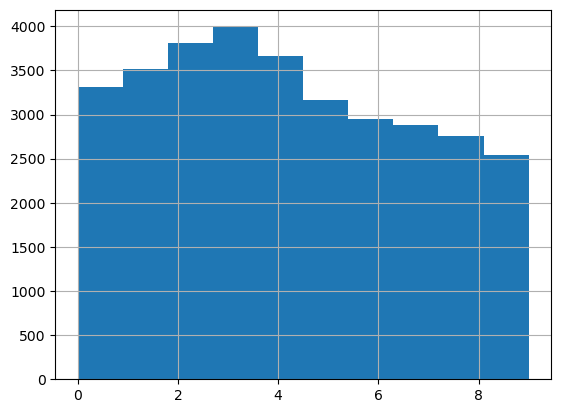

In [10]:
info["imd_band_enc"].hist()

In [11]:
reg['date_unregistration'].value_counts().sum()

10072

In [12]:
reg[reg.duplicated()]

,code_module,code_presentation,id_student,date_registration,date_unregistration


In [13]:
info[info.duplicated()]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_enc


In [14]:
info[info["id_student"].duplicated()]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_enc
395,AAA,2014J,65002,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,1,60,N,Fail,7
403,AAA,2014J,94961,M,South Region,Lower Than A Level,70-80%,35-55,1,60,N,Pass,7
415,AAA,2014J,129955,M,West Midlands Region,A Level or Equivalent,50-60%,0-35,1,60,N,Withdrawn,5
422,AAA,2014J,135335,F,East Anglian Region,Lower Than A Level,20-30%,0-35,1,120,N,Withdrawn,2
423,AAA,2014J,135400,F,South East Region,Lower Than A Level,90-100%,35-55,1,60,Y,Pass,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31964,GGG,2014J,600320,F,West Midlands Region,Lower Than A Level,40-50%,35-55,1,30,Y,Pass,4
31966,GGG,2014J,603585,M,West Midlands Region,Lower Than A Level,30-40%,35-55,1,30,N,Fail,3
31994,GGG,2014J,624767,F,London Region,A Level or Equivalent,90-100%,35-55,1,30,N,Distinction,9
32003,GGG,2014J,627812,F,Yorkshire Region,Lower Than A Level,60-70%,0-35,1,30,N,Distinction,6


In [15]:
info["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [16]:
info=info.merge(reg,on=["id_student","code_module","code_presentation"])

In [17]:
info.shape

(32593, 15)

In [18]:
info[info.duplicated()]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_enc,date_registration,date_unregistration


In [19]:
info[info["id_student"]==65002]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_enc,date_registration,date_unregistration
15,AAA,2013J,65002,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,0,60,N,Withdrawn,7,-180.0,96.0
395,AAA,2014J,65002,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,1,60,N,Fail,7,-144.0,NaN


In [20]:
e3= e3.drop(columns=["Unnamed: 0"])

In [21]:
e3

,id_student,code_module,code_presentation,dataplus,dualpane,externalquiz,folder,forumng,glossary,homepage,...,ouwiki,page,questionnaire,quiz,repeatactivity,resource,sharedsubpage,subpage,url,total_clicks
0,6516,AAA,2014J,0.007524,0.000000,0.000000,0.0,0.161591,0.0,0.178072,...,0.000000,0.0,0.0,0.000000,0.0,0.011107,0.0,0.051236,0.051236,2791
1,8462,DDD,2013J,0.000000,0.000000,0.018576,0.0,0.055728,0.0,0.284830,...,0.027864,0.0,0.0,0.000000,0.0,0.108359,0.0,0.351393,0.035604,646
2,8462,DDD,2014J,0.000000,0.000000,0.000000,0.0,0.200000,0.0,0.700000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,10
3,11391,AAA,2013J,0.000000,0.000000,0.000000,0.0,0.206638,0.0,0.147752,...,0.000000,0.0,0.0,0.000000,0.0,0.013919,0.0,0.034261,0.005353,934
4,23629,BBB,2013B,0.000000,0.000000,0.000000,0.0,0.540373,0.0,0.223602,...,0.000000,0.0,0.0,0.192547,0.0,0.012422,0.0,0.031056,0.000000,161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29223,2698257,AAA,2013J,0.000000,0.000000,0.000000,0.0,0.265172,0.0,0.217678,...,0.000000,0.0,0.0,0.000000,0.0,0.015831,0.0,0.058047,0.006596,758
29224,2698535,CCC,2014B,0.000000,0.000000,0.000000,0.0,0.393130,0.0,0.124682,...,0.000000,0.0,0.0,0.371501,0.0,0.029262,0.0,0.066158,0.007634,786
29225,2698535,EEE,2013J,0.000000,0.000579,0.000000,0.0,0.565268,0.0,0.113169,...,0.034443,0.0,0.0,0.032127,0.0,0.000868,0.0,0.003763,0.026049,3455
29226,2698577,BBB,2014J,0.000000,0.000000,0.000000,0.0,0.143654,0.0,0.284519,...,0.000000,0.0,0.0,0.100418,0.0,0.052999,0.0,0.052999,0.005579,717


In [22]:
info.loc[
    (info["final_result"] == "Withdrawn") &
    (info["date_unregistration"].isna()),
    ["code_module","code_presentation","id_student","final_result", "date_unregistration"]
]

,code_module,code_presentation,id_student,final_result,date_unregistration
6315,BBB,2014B,2512349,Withdrawn,NaN
6484,BBB,2014J,271047,Withdrawn,NaN
6601,BBB,2014J,417978,Withdrawn,NaN
7247,BBB,2014J,636660,Withdrawn,NaN
7410,BBB,2014J,647876,Withdrawn,NaN
...,...,...,...,...,...
29978,FFF,2014J,2398260,Withdrawn,NaN
30032,FFF,2014J,2622634,Withdrawn,NaN
30562,GGG,2013J,590248,Withdrawn,NaN
32149,GGG,2014J,646891,Withdrawn,NaN


In [23]:
info[info["id_student"]==271047]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_enc,date_registration,date_unregistration
6484,BBB,2014J,271047,F,South West Region,Lower Than A Level,90-100%,0-35,0,60,N,Withdrawn,9,-25.0,NaN


In [24]:
mask = (
    (info["final_result"] == "Withdrawn") &
    (info["date_unregistration"].isna())
)

fill_value = (
    info.loc[
        (info["final_result"] == "Withdrawn") &
        (~info["date_unregistration"].isna()),
        "date_unregistration"
    ].median()      # or .mean()
)

info.loc[mask, "date_unregistration"] = fill_value

In [25]:
info.loc[
    (info["final_result"] == "Withdrawn") &
    (info["date_unregistration"].isna()),
    ["code_module","code_presentation","id_student","final_result", "date_unregistration"]
]

,code_module,code_presentation,id_student,final_result,date_unregistration


In [26]:
#info = info[(info["code_module"] == "BBB") &(info["code_presentation"] == "2014J")]

In [27]:
svle['week'] = (svle['date'] // 7)+1

In [28]:
a = svle[['week','date']]
a[a['date']==0]

,week,date
10847,1,0
10848,1,0
10849,1,0
10850,1,0
10851,1,0
...,...,...
10546559,1,0
10546560,1,0
10546561,1,0
10546562,1,0


In [29]:
for w in [1, 2, 3]:
    wk = (svle[svle['week'] == w].groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().rename(f'clicks_week{w}'))
    info = info.merge(wk, on=['id_student', 'code_module', 'code_presentation'], how='left')
    info[f'clicks_week{w}'] = info[f'clicks_week{w}'].fillna(0).astype(int)

In [30]:
info[['id_student','clicks_week1','clicks_week2','clicks_week3']]

,id_student,clicks_week1,clicks_week2,clicks_week3
0,11391,183,20,100
1,28400,175,66,37
2,30268,107,72,0
3,31604,22,154,108
4,32885,61,116,37
...,...,...,...,...
32588,2640965,1,16,22
32589,2645731,0,0,56
32590,2648187,9,0,0
32591,2679821,4,0,0


In [31]:
info.describe()

,id_student,num_of_prev_attempts,studied_credits,imd_band_enc,date_registration,date_unregistration,clicks_week1,clicks_week2,clicks_week3
count,3.259300e+04,32593.000000,32593.000000,32593.000000,32548.000000,10165.000000,32593.000000,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691,4.184948,-69.411300,49.549434,61.764090,55.154420,70.784524
std,5.491673e+05,0.479758,41.071900,2.776483,49.260522,82.111364,104.955012,90.106378,103.486930
min,3.733000e+03,0.000000,30.000000,0.000000,-322.000000,-365.000000,0.000000,0.000000,0.000000
25%,5.085730e+05,0.000000,60.000000,2.000000,-100.000000,-1.000000,0.000000,0.000000,0.000000
50%,5.903100e+05,0.000000,60.000000,4.000000,-57.000000,27.000000,24.000000,20.000000,31.000000
75%,6.444530e+05,0.000000,120.000000,7.000000,-29.000000,108.000000,81.000000,72.000000,102.000000
max,2.716795e+06,6.000000,655.000000,9.000000,167.000000,444.000000,4385.000000,1566.000000,1709.000000


In [32]:
info['click_trend'] = info['clicks_week3'] - info['clicks_week1']

In [33]:
info = info.merge(e3,on=['id_student', 'code_module', 'code_presentation'])

In [34]:
info.isna().sum()

code_module                 0
code_presentation           0
id_student                  0
gender                      0
region                      0
highest_education           0
imd_band                 1054
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
imd_band_enc                0
date_registration           7
date_unregistration     22052
clicks_week1                0
clicks_week2                0
clicks_week3                0
click_trend                 0
dataplus                    0
dualpane                    0
externalquiz                0
folder                      0
forumng                     0
glossary                    0
homepage                    0
htmlactivity                0
oucollaborate               0
oucontent                   0
ouelluminate                0
ouwiki                      0
page                        0
questionnaire               0
quiz      

In [35]:
info=info.merge(course,  on=['code_module','code_presentation'], how='left')
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,page,questionnaire,quiz,repeatactivity,resource,sharedsubpage,subpage,url,total_clicks,module_presentation_length
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,0.0,0.0,0.000000,0.0,0.013919,0.0,0.034261,0.005353,934,268
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,0.0,0.0,0.000000,0.0,0.008362,0.0,0.060627,0.033449,1435,268
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.0,0.000000,0.0,0.014235,0.0,0.078292,0.014235,281,268
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,0.0,0.0,0.000000,0.0,0.008804,0.0,0.066728,0.041705,2158,268
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,0.0,0.0,0.000000,0.0,0.043520,0.0,0.076402,0.013540,1034,268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29223,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,...,0.0,0.0,0.000000,0.0,0.097561,0.0,0.219512,0.000000,41,269
29224,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,...,0.0,0.0,0.170213,0.0,0.122060,0.0,0.052632,0.000000,893,269
29225,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,...,0.0,0.0,0.416667,0.0,0.060897,0.0,0.064103,0.000000,312,269
29226,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,...,0.0,0.0,0.112727,0.0,0.032727,0.0,0.043636,0.000000,275,269


In [36]:
last_click = svle.groupby(['id_student', 'code_module', 'code_presentation'])['date'].max().rename('last_click_day')
info = info.merge(last_click, on=['id_student', 'code_module', 'code_presentation'], how='left')
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,questionnaire,quiz,repeatactivity,resource,sharedsubpage,subpage,url,total_clicks,module_presentation_length,last_click_day
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,0.0,0.000000,0.0,0.013919,0.0,0.034261,0.005353,934,268,253
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,0.0,0.000000,0.0,0.008362,0.0,0.060627,0.033449,1435,268,239
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.000000,0.0,0.014235,0.0,0.078292,0.014235,281,268,12
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,0.0,0.000000,0.0,0.008804,0.0,0.066728,0.041705,2158,268,264
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,0.0,0.000000,0.0,0.043520,0.0,0.076402,0.013540,1034,268,247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29223,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,...,0.0,0.000000,0.0,0.097561,0.0,0.219512,0.000000,41,269,19
29224,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,...,0.0,0.170213,0.0,0.122060,0.0,0.052632,0.000000,893,269,247
29225,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,...,0.0,0.416667,0.0,0.060897,0.0,0.064103,0.000000,312,269,227
29226,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,...,0.0,0.112727,0.0,0.032727,0.0,0.043636,0.000000,275,269,100


In [37]:
info['days_since_last_click'] = info['module_presentation_length']-info['last_click_day']
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,quiz,repeatactivity,resource,sharedsubpage,subpage,url,total_clicks,module_presentation_length,last_click_day,days_since_last_click
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,0.000000,0.0,0.013919,0.0,0.034261,0.005353,934,268,253,15
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,0.000000,0.0,0.008362,0.0,0.060627,0.033449,1435,268,239,29
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.000000,0.0,0.014235,0.0,0.078292,0.014235,281,268,12,256
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,0.000000,0.0,0.008804,0.0,0.066728,0.041705,2158,268,264,4
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,0.000000,0.0,0.043520,0.0,0.076402,0.013540,1034,268,247,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29223,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,...,0.000000,0.0,0.097561,0.0,0.219512,0.000000,41,269,19,250
29224,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,...,0.170213,0.0,0.122060,0.0,0.052632,0.000000,893,269,247,22
29225,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,...,0.416667,0.0,0.060897,0.0,0.064103,0.000000,312,269,227,42
29226,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,...,0.112727,0.0,0.032727,0.0,0.043636,0.000000,275,269,100,169


In [38]:
info['days_since_last_click'].describe()

count    29228.000000
mean        78.839880
std         89.832486
min          0.000000
25%          8.000000
50%         27.000000
75%        158.000000
max        292.000000
Name: days_since_last_click, dtype: float64

In [39]:
unique_res = svle.groupby(['id_student', 'code_module', 'code_presentation'])['id_site'].nunique().rename('unique_resources')
info = info.merge(unique_res, on=['id_student', 'code_module', 'code_presentation'], how='left')
info['unique_resources'] = info['unique_resources'].fillna(0).astype(int)
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,repeatactivity,resource,sharedsubpage,subpage,url,total_clicks,module_presentation_length,last_click_day,days_since_last_click,unique_resources
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,0.0,0.013919,0.0,0.034261,0.005353,934,268,253,15,55
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,0.0,0.008362,0.0,0.060627,0.033449,1435,268,239,29,84
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.014235,0.0,0.078292,0.014235,281,268,12,256,22
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,0.0,0.008804,0.0,0.066728,0.041705,2158,268,264,4,82
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,0.0,0.043520,0.0,0.076402,0.013540,1034,268,247,21,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29223,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,...,0.0,0.097561,0.0,0.219512,0.000000,41,269,19,250,8
29224,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,...,0.0,0.122060,0.0,0.052632,0.000000,893,269,247,22,50
29225,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,...,0.0,0.060897,0.0,0.064103,0.000000,312,269,227,42,28
29226,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,...,0.0,0.032727,0.0,0.043636,0.000000,275,269,100,169,17


In [40]:
info[['clicks_week1','clicks_week2','clicks_week3','click_trend','days_since_last_click','unique_resources']].describe().round(3)

,clicks_week1,clicks_week2,clicks_week3,click_trend,days_since_last_click,unique_resources
count,29228.000,29228.000,29228.000,29228.000,29228.000,29228.000
mean,68.875,61.504,78.934,10.059,78.840,67.076
std,108.600,93.077,106.298,108.741,89.832,54.953
min,0.000,0.000,0.000,-4205.000,0.000,1.000
25%,4.000,3.000,5.000,-26.000,8.000,27.000
50%,32.000,28.000,41.000,0.000,27.000,51.000
75%,90.000,81.000,113.000,48.000,158.000,93.000
max,4385.000,1566.000,1709.000,1454.000,292.000,413.000


In [41]:
info['days_since_last_click']=info['days_since_last_click'].fillna(info['module_presentation_length']).astype(int)

In [42]:
info[['clicks_week1','clicks_week2','clicks_week3','click_trend','days_since_last_click','unique_resources']].describe().round(3)

,clicks_week1,clicks_week2,clicks_week3,click_trend,days_since_last_click,unique_resources
count,29228.000,29228.000,29228.000,29228.000,29228.000,29228.000
mean,68.875,61.504,78.934,10.059,78.840,67.076
std,108.600,93.077,106.298,108.741,89.832,54.953
min,0.000,0.000,0.000,-4205.000,0.000,1.000
25%,4.000,3.000,5.000,-26.000,8.000,27.000
50%,32.000,28.000,41.000,0.000,27.000,51.000
75%,90.000,81.000,113.000,48.000,158.000,93.000
max,4385.000,1566.000,1709.000,1454.000,292.000,413.000


In [43]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29228 entries, 0 to 29227
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 29228 non-null  object 
 1   code_presentation           29228 non-null  object 
 2   id_student                  29228 non-null  int64  
 3   gender                      29228 non-null  object 
 4   region                      29228 non-null  object 
 5   highest_education           29228 non-null  object 
 6   imd_band                    28174 non-null  object 
 7   age_band                    29228 non-null  object 
 8   num_of_prev_attempts        29228 non-null  int64  
 9   studied_credits             29228 non-null  int64  
 10  disability                  29228 non-null  object 
 11  final_result                29228 non-null  object 
 12  imd_band_enc                29228 non-null  int32  
 13  date_registration           292

In [44]:
info['registered_late'] = (info['date_registration'] > 0).astype(int)
info['unregistered_early'] = (
    info['date_unregistration'].notna() &
    (info['date_unregistration'] < info['module_presentation_length'])
).astype(int)

In [45]:
info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,sharedsubpage,subpage,url,total_clicks,module_presentation_length,last_click_day,days_since_last_click,unique_resources,registered_late,unregistered_early
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,0.0,0.034261,0.005353,934,268,253,15,55,0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,0.0,0.060627,0.033449,1435,268,239,29,84,0,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.078292,0.014235,281,268,12,256,22,0,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,0.0,0.066728,0.041705,2158,268,264,4,82,0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,0.0,0.076402,0.013540,1034,268,247,21,66,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29223,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,...,0.0,0.219512,0.000000,41,269,19,250,8,0,0
29224,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,...,0.0,0.052632,0.000000,893,269,247,22,50,0,0
29225,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,...,0.0,0.064103,0.000000,312,269,227,42,28,0,0
29226,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,...,0.0,0.043636,0.000000,275,269,100,169,17,0,1


In [46]:
info.drop(columns=['date_registration', 'date_unregistration'], inplace=True)

In [47]:
eduo = {'No Formal quals': 0, 'Lower Than A Level': 1,
             'A Level or Equivalent': 2, 'HE Qualification': 3,
             'Post Graduate Qualification': 4}
info['education_enc'] = info['highest_education'].map(eduo)

In [48]:
ageo = {'0-35':1,'35-55':2,'55<=':3}
info['age_enc'] = info['age_band'].map(ageo).astype(int)

In [49]:
reso = {'Pass': 0, 'Distinction': 0, 'Fail': 1, 'Withdrawn': 1}
info['at_risk'] = info['final_result'].map(reso)

In [50]:
engineered= info[["gender","region","num_of_prev_attempts","studied_credits",
                  "disability","clicks_week1","clicks_week2","clicks_week3",
                  "click_trend","module_presentation_length","last_click_day",
                  "days_since_last_click","unique_resources","registered_late",
                  "unregistered_early","imd_band_enc","education_enc","age_enc",
                  "at_risk","dataplus","dualpane","externalquiz","folder","forumng",
                  "glossary","homepage","htmlactivity","oucollaborate","oucontent",
                  "ouelluminate","ouwiki","page","questionnaire","quiz","repeatactivity",
                  "resource","sharedsubpage","subpage","url","total_clicks"]]

In [51]:
e2 = pd.get_dummies(engineered,dtype=int)

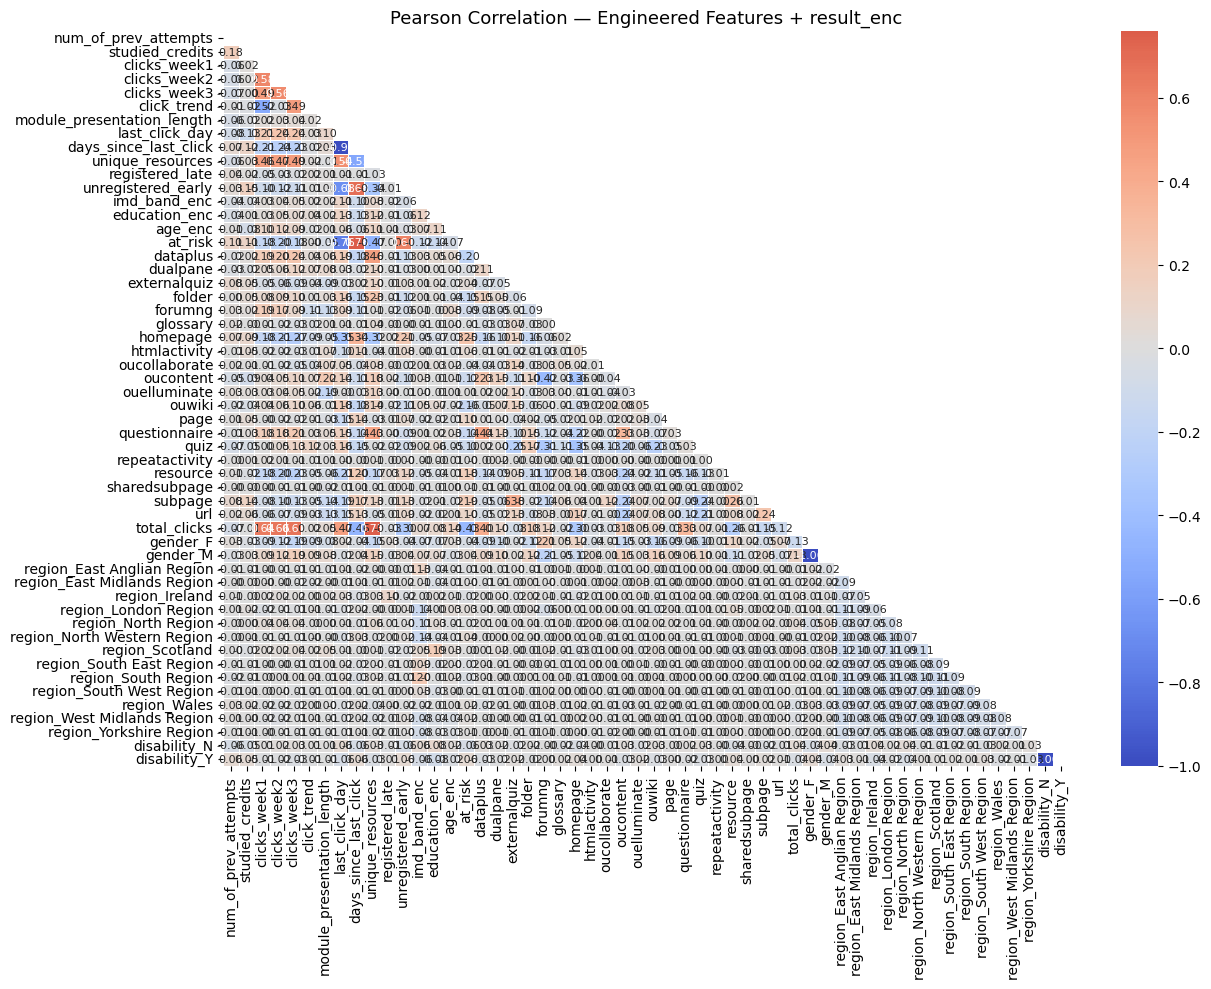

In [52]:
corr_df = e2.corr()
mask    = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Pearson Correlation — Engineered Features + result_enc', fontsize=13)
plt.tight_layout()
plt.show()

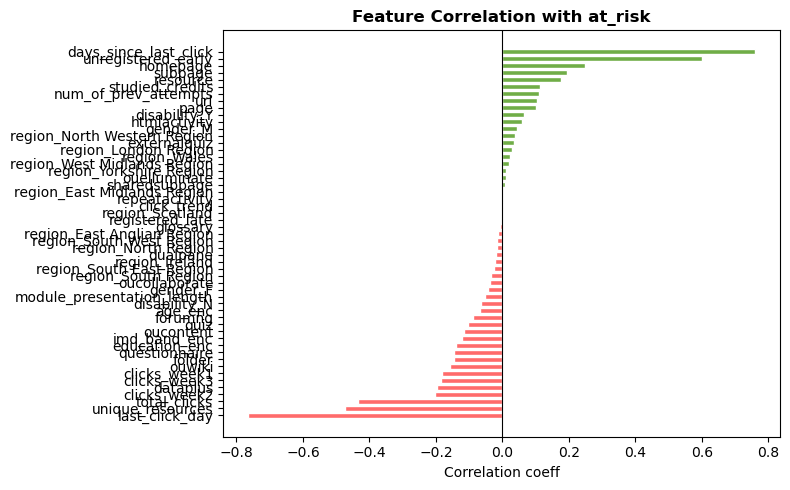


Correlation values:


,at_risk
last_click_day,-0.764
unique_resources,-0.472
total_clicks,-0.434
clicks_week2,-0.202
dataplus,-0.197
clicks_week3,-0.184
clicks_week1,-0.181
ouwiki,-0.158
folder,-0.146
questionnaire,-0.144


In [53]:
target_corr = e2.corr()['at_risk'].drop('at_risk').sort_values()

colors = ['#FF6B6B' if v < 0 else '#70AD47' for v in target_corr.values]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with at_risk', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation coeff')
plt.tight_layout()
plt.show()

print('\nCorrelation values:')
display(target_corr.round(3).to_frame())

In [54]:
e2= e2.drop(columns=["last_click_day"])

In [55]:
e2.to_csv('engine3.csv', index=False)